In [ ]:
from google.colab import drive
import os
import zipfile

print("--- Kết nối Google Drive ---")
drive.mount('/content/drive')

path_owner = '/content/drive/MyDrive/Deepfake_project/project_data.zip'
path_shared = '/content/drive/Shareddrives/Deepfake_project/project_data.zip'

if os.path.exists(path_owner):
    zip_path = path_owner
    print("[OK] Đã tìm thấy file ZIP.")
elif os.path.exists('/content/drive/MyDrive/Deepfake_project/project_data.zip'):
    zip_path = '/content/drive/MyDrive/Deepfake_project/project_data.zip'
    print("[OK] Đã tìm thấy file ZIP.")
else:
    zip_path = None
    print("[LỖI] Không tìm thấy file ZIP.")

if zip_path:
    print("--- Đang tiến hành giải nén 40.000 ảnh lên Cloud Colab... ---")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

    num_real = len(os.listdir('/content/project_data/real'))
    num_fake = len(os.listdir('/content/project_data/fake'))
    print(f"\n[THÀNH CÔNG] Dữ liệu đã bung ra Colab gọn gàng:")
    print(f" -> Ảnh THẬT (Real): {num_real} tấm")
    print(f" -> Ảnh GIẢ (Fake): {num_fake} tấm")

--- Kết nối Google Drive ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[LỖI] Không tìm thấy file ZIP.


--- Đang tiến hành tiền xử lý và trích xuất ảnh dư PCA ---


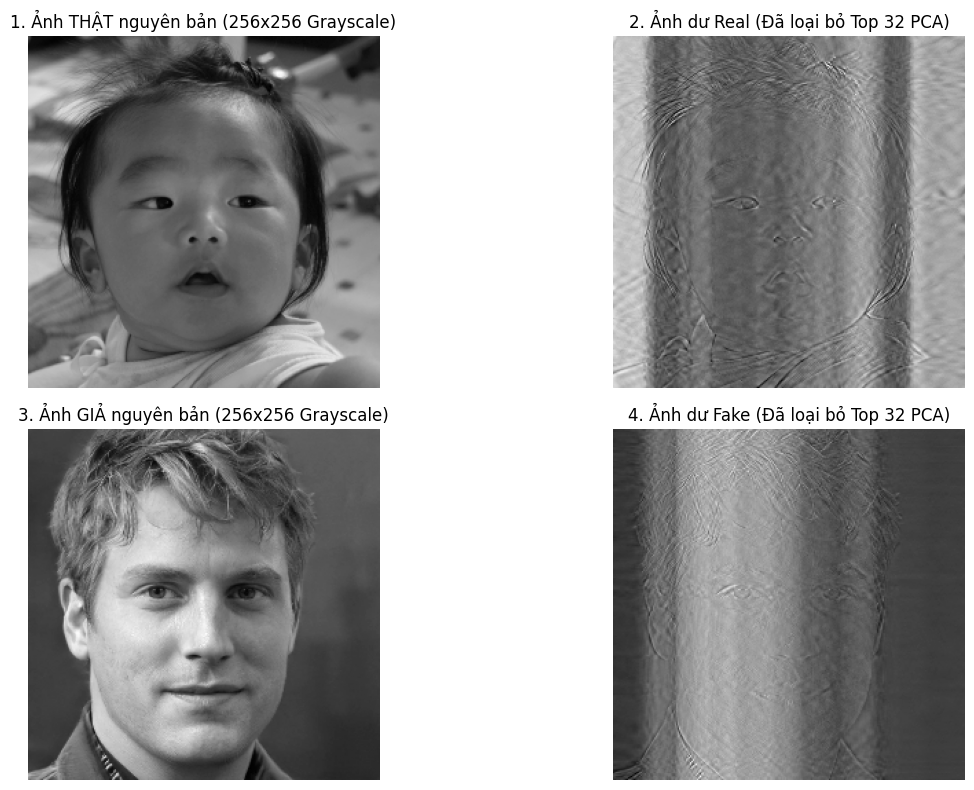


[THÀNH CÔNG] Tiền xử lý hoàn tất!
 -> Kích thước ma trận ảnh dư Real: (256, 256)
 -> Kích thước ma trận ảnh dư Fake: (256, 256)


In [ ]:
# ========================================================
# QUY TRÌNH TIỀN XỬ LÝ: ĐỌC ẢNH, RESIZE VÀ TRÍCH XUẤT ẢNH DƯ PCA
# ========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- ĐỊNH NGHĨA HÀM TRÍCH XUẤT ẢNH DƯ PCA CHUẨN BASELINE ---
def get_pca_residual_image(img_gray, num_components_to_remove=32):
    # Đảm bảo ảnh ở dạng float64 phục vụ toán học ma trận
    img_data = img_gray.astype(np.float64)

    # Khởi tạo thuật toán PCA
    pca = PCA()
    pca.fit(img_data)

    # Biến đổi ảnh sang không gian các thành phần chính
    img_transformed = pca.transform(img_data)

    # Tạo bản sao và loại bỏ Top N thành phần tương quan cao (High-correlation signals)
    img_transformed_residual = img_transformed.copy()
    img_transformed_residual[:, :num_components_to_remove] = 0

    # Nghịch đảo ma trận để tái cấu trúc lại thành ảnh dư (Residual Image)
    residual_data = pca.inverse_transform(img_transformed_residual)

    # Chuẩn hóa giá trị pixel về đoạn [0, 255] định dạng uint8
    residual_img_8u = cv2.convertScaleAbs(residual_data)

    return residual_img_8u


# --- TIỀN XỬ LÝ VÀ CHẠY THỬ NGHIỆM TRÊN ẢNH MẪU ---
print("--- Đang tiến hành tiền xử lý và trích xuất ảnh dư PCA ---")

# Lấy danh sách file ảnh thật và giả
real_files = [f for f in os.listdir('/content/project_data/real') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
fake_files = [f for f in os.listdir('/content/project_data/fake') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if len(real_files) > 0 and len(fake_files) > 0:
    real_sample_path = os.path.join('/content/project_data/real', real_files[0])
    fake_sample_path = os.path.join('/content/project_data/fake', fake_files[0])

    # 1. Đọc ảnh xám (Grayscale)
    img_real_raw = cv2.imread(real_sample_path, cv2.IMREAD_GRAYSCALE)
    img_fake_raw = cv2.imread(fake_sample_path, cv2.IMREAD_GRAYSCALE)

    # 2. Thay đổi kích thước về độ phân giải chuẩn 256x256 để tối ưu tài nguyên
    img_real_resized = cv2.resize(img_real_raw, (256, 256))
    img_fake_resized = cv2.resize(img_fake_raw, (256, 256))

    # 3. Trích xuất ảnh dư bằng cách loại bỏ N=32 thành phần chính (Theo Mục 6 trong Paper)
    N_components = 32
    residual_real = get_pca_residual_image(img_real_resized, num_components_to_remove=N_components)
    residual_fake = get_pca_residual_image(img_fake_resized, num_components_to_remove=N_components)

    # --- TRỰC QUAN HÓA KẾT QUẢ ĐẦU RA ---
    plt.figure(figsize=(14, 8))

    # Ảnh thật gốc (đã resize)
    plt.subplot(2, 2, 1)
    plt.imshow(img_real_resized, cmap='gray')
    plt.title("1. Ảnh THẬT nguyên bản (256x256 Grayscale)")
    plt.axis('off')

    # Ảnh dư của ảnh thật (Tín hiệu tương quan thấp)
    plt.subplot(2, 2, 2)
    plt.imshow(residual_real, cmap='gray')
    plt.title(f"2. Ảnh dư Real (Đã loại bỏ Top {N_components} PCA)")
    plt.axis('off')

    # Ảnh giả gốc (đã resize)
    plt.subplot(2, 2, 3)
    plt.imshow(img_fake_resized, cmap='gray')
    plt.title("3. Ảnh GIẢ nguyên bản (256x256 Grayscale)")
    plt.axis('off')

    # Ảnh dư của ảnh giả (Tín hiệu tương quan thấp)
    plt.subplot(2, 2, 4)
    plt.imshow(residual_fake, cmap='gray')
    plt.title(f"4. Ảnh dư Fake (Đã loại bỏ Top {N_components} PCA)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n[THÀNH CÔNG] Tiền xử lý hoàn tất!")
    print(f" -> Kích thước ma trận ảnh dư Real: {residual_real.shape}")
    print(f" -> Kích thước ma trận ảnh dư Fake: {residual_fake.shape}")
else:
    print("[LỖI] Không tìm thấy ảnh trong thư mục /content/project_data/. Hãy chắc chắn bạn đã giải nén thành công dữ liệu ở Ô số 1.")

In [ ]:
import gdown, zipfile, os

file_id = '1hKCgB5upHkUhb-baWL_2zN74JQoYC7A4'
zip_path = '/content/project_data.zip'

print('Dang tai file...')
gdown.download(f'https://drive.google.com/uc?id={file_id}', zip_path, quiet=False)

print('Dang giai nen...')
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/')

print(f"Real: {len(os.listdir('/content/project_data/real'))} anh")
print(f"Fake: {len(os.listdir('/content/project_data/fake'))} anh")

Dang tai file...


Downloading...
From (original): https://drive.google.com/uc?id=1hKCgB5upHkUhb-baWL_2zN74JQoYC7A4
From (redirected): https://drive.google.com/uc?id=1hKCgB5upHkUhb-baWL_2zN74JQoYC7A4&confirm=t&uuid=dc48c791-d228-408e-b439-8669736d4b99
To: /content/project_data.zip
100%|██████████| 10.3G/10.3G [02:28<00:00, 69.0MB/s]


Dang giai nen...
Real: 20000 anh
Fake: 20000 anh


In [ ]:
!pip install scikit-image tqdm -q

In [ ]:
import os, pickle
import numpy as np
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from tqdm import tqdm

OUTPUT_DIR = '/content/features'
FFT_BINS, LBP_BINS, NOISE_BINS = 64, 59, 64
N_components = 32
os.makedirs(OUTPUT_DIR, exist_ok=True)

def extract_fft(gray):
    f = np.fft.fft2(gray.astype(np.float32))
    mag = np.log1p(np.abs(np.fft.fftshift(f)))
    hist, _ = np.histogram(mag, bins=FFT_BINS, range=(mag.min(), mag.max()))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

def extract_lbp(gray):
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=LBP_BINS, range=(0, LBP_BINS))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

def extract_noise(gray):
    noise = gray.astype(np.float32) - cv2.GaussianBlur(gray, (5,5), 0).astype(np.float32)
    hist, _ = np.histogram(noise, bins=NOISE_BINS, range=(-50, 50))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

X_all, y_all, paths_all = [], [], []
for label_name, label_idx in [('real', 0), ('fake', 1)]:
    folder = f'/content/project_data/{label_name}'
    files = sorted([f for f in os.listdir(folder)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f'\n[{label_name.upper()}] {len(files)} anh')
    for fname in tqdm(files, desc=label_name):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (256, 256))
        residual = get_pca_residual_image(img, num_components_to_remove=N_components)
        feat = np.concatenate([extract_fft(residual), extract_lbp(residual), extract_noise(residual)])
        X_all.append(feat)
        y_all.append(label_idx)
        paths_all.append(os.path.join(folder, fname))

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
print(f'\nTong: {len(y_all)} | real={(y_all==0).sum()} fake={(y_all==1).sum()}')

idx = np.arange(len(y_all))
idx_train, idx_tmp, y_tr, y_tmp = train_test_split(
    idx, y_all, test_size=0.2, stratify=y_all, random_state=42)
idx_val, idx_test, _, _ = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

splits = {
    'train': (X_all[idx_train], y_all[idx_train], [paths_all[i] for i in idx_train]),
    'val':   (X_all[idx_val],   y_all[idx_val],   [paths_all[i] for i in idx_val]),
    'test':  (X_all[idx_test],  y_all[idx_test],  [paths_all[i] for i in idx_test]),
}
for name, (Xs, ys, _) in splits.items():
    print(f'  {name}: {len(ys)} anh | real={(ys==0).sum()} fake={(ys==1).sum()}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(splits['train'][0])
X_val_sc   = scaler.transform(splits['val'][0])
X_test_sc  = scaler.transform(splits['test'][0])

fnames = ([f'fft_{i}' for i in range(FFT_BINS)] +
          [f'lbp_{i}' for i in range(LBP_BINS)] +
          [f'noise_{i}' for i in range(NOISE_BINS)])
config = {'img_size': 256, 'pca_remove': 32, 'feature_dim': 187, 'split': '80/10/10'}

for name, Xs, split_t in [('train', X_train_sc, splits['train']),
                           ('val',   X_val_sc,   splits['val']),
                           ('test',  X_test_sc,  splits['test'])]:
    _, ys, ps = split_t
    with open(f'{OUTPUT_DIR}/{name}.pkl', 'wb') as f:
        pickle.dump({'X': Xs, 'y': ys, 'paths': ps,
                     'feature_names': fnames, 'config': config}, f)
    print(f'Luu {name}.pkl shape={Xs.shape}')

with open(f'{OUTPUT_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

fft_s, lbp_s, noise_s = slice(0,64), slice(64,123), slice(123,None)
variants = {
    'full':       X_train_sc,
    'no_fft':     np.hstack([X_train_sc[:,lbp_s],   X_train_sc[:,noise_s]]),
    'no_lbp':     np.hstack([X_train_sc[:,fft_s],   X_train_sc[:,noise_s]]),
    'no_noise':   np.hstack([X_train_sc[:,fft_s],   X_train_sc[:,lbp_s]]),
    'only_fft':   X_train_sc[:,fft_s],
    'only_lbp':   X_train_sc[:,lbp_s],
    'only_noise': X_train_sc[:,noise_s],
}
with open(f'{OUTPUT_DIR}/train_ablation.pkl', 'wb') as f:
    pickle.dump({'variants': variants, 'y': splits['train'][1],
                 'variant_names': list(variants.keys())}, f)

print('\nXONG! Giao team C: train.pkl, val.pkl, test.pkl, scaler.pkl')


[REAL] 20000 anh


real: 100%|██████████| 20000/20000 [50:44<00:00,  6.57it/s]



[FAKE] 20000 anh


fake: 100%|██████████| 20000/20000 [47:36<00:00,  7.00it/s]



Tong: 40000 | real=20000 fake=20000
  train: 32000 anh | real=16000 fake=16000
  val: 4000 anh | real=2000 fake=2000
  test: 4000 anh | real=2000 fake=2000
Luu train.pkl shape=(32000, 187)
Luu val.pkl shape=(4000, 187)
Luu test.pkl shape=(4000, 187)

XONG! Giao team C: train.pkl, val.pkl, test.pkl, scaler.pkl


In [ ]:
import shutil, os

# Lưu lên Drive của bạn
os.makedirs('/content/drive/MyDrive/Deepfake_project/features', exist_ok=True)

for fname in ['train.pkl', 'val.pkl', 'test.pkl', 'scaler.pkl', 'train_ablation.pkl']:
    shutil.copy(f'/content/features/{fname}',
                f'/content/drive/MyDrive/Deepfake_project/features/{fname}')
    print(f'Da luu: {fname}')

print('Xong! File an toan tren Drive.')

Da luu: train.pkl
Da luu: val.pkl
Da luu: test.pkl
Da luu: scaler.pkl
Da luu: train_ablation.pkl
Xong! File an toan tren Drive.
